## Bibliotecas

In [1]:
import pandas as pd
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
import logging
import datetime
import time

from datetime import datetime

from pyspark.sql.functions import col, datediff
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

import calendar
import pandas as pd
import plotly.express as px
from pyspark.sql import SparkSession
from pyspark.sql.functions import concat, col
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from ipywidgets import interact, widgets
from matplotlib.dates import MonthLocator, DateFormatter
import geopandas as gpd
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
#from fbprophet import Prophet
from sklearn.metrics import mean_squared_error
import numpy as np
import plotly.graph_objects as go
from pyspark.sql import functions as F
from pyspark.sql.functions import year, month
from sklearn.metrics.pairwise import euclidean_distances
from pyspark.sql.functions import year, month, sum as sum_
from scipy.spatial.distance import euclidean
from prophet import Prophet
from pyspark.sql.functions import col, countDistinct , desc , count , length
from pyspark.sql.functions import split, col, when
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf, dayofmonth, last_day ,to_date, lit, isnull
from pyspark.sql.types import IntegerType
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from dateutil.relativedelta import relativedelta
from pyspark.sql.functions import date_format

from pyspark.sql.functions import col, coalesce, current_date, months_between, round
from pyspark.sql.functions import regexp_replace

import schedule
from pyspark.sql.functions import col, to_timestamp, date_format

import pyspark
import pandas as pd
import boto3
import sagemaker
import sagemaker.feature_store.feature_store as fs
import databricks.connect
from dateutil.relativedelta import relativedelta

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.metrics import mean_squared_error, root_mean_squared_error

import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import plotly.graph_objects as go
from itertools import product
import random
import statsmodels.api as sm
import os

from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, months_between, current_date,expr
from pyspark.sql.functions import col, substr

import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
from databricks.connect import DatabricksSession


# Get spark
spark = databricks.connect.DatabricksSession.builder.getOrCreate()

c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\pydantic\_internal\_fields.py:192: UserWarning: Field name "json" in "MonitoringDatasetFormat" shadows an attribute in parent "Base"
  warnings.warn(


[02/19/25 13:00:50] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=870350;file://c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\botocore\credentials.py\credentials.py]8;;\:]8;id=335037;file://c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\botocore\credentials.py#1278\1278]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: C:\ProgramData\sagemaker\sagemaker\config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: C:\Users\gusta\AppData\Local\sagemaker\sagemaker\config.yaml


In [2]:
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")

### Tabelas Usadas

In [3]:
cliente = spark.table("prd.dl_redeok_checkok.tb_cliente") # Tabela com data inici, data final , motivo do bloqueio e max_conexao = next_status , cnpj
revenda = spark.table("prd.dl_redeok_checkok.tb_revenda") # Só usamos para filtrar os contratos tipo revenda
receber = spark.table("prd.dl_redeok_checkok.vw_receber") # Tabela de faturas
estab_df = spark.table("prd.dl_receita_federal.tb_estabelecimento").alias("estab") \
    .withColumn("CNPJ_CPF", concat(col("cnpj_basico"), col("cnpj_ordem"), col("cnpj_dv")))
hierarquia_sdf = spark.table("dev.dw_rok.tb_cnae_hierarquia_comercial").alias("hierarquia")


In [4]:
# Selecionar as colunas desejadas no estab_df
estab_selected = estab_df.select("CNPJ_CPF", "cnae_fiscal_principal","uf","data_inicio_atividade")

# Realizar o join com hierarquia_sdf utilizando a coluna cnae_fiscal_principal e CNAE_RF
resultado_df = estab_selected.join(hierarquia_sdf, estab_selected["cnae_fiscal_principal"] == hierarquia_sdf["CNAE_RF"], "left")

# Suponha que df seja seu DataFrame
#resultado_df = resultado_df.withColumn("ano_nascimento", substr(col("data_inicio_atividade"), 1, 4))

resultado_df = resultado_df.select("CNPJ_CPF", "CNAE_RF", "Hierarquia","uf","data_inicio_atividade")


### Querry

In [5]:
query=  """WITH 
-- CTE para obter informações básicas dos clientes, como quantidade de contratos, primeiro e último bloqueio, motivo e status de conexão
clientes AS 
(
    SELECT 
          COUNT(1)              AS contratos          -- Contagem total de contratos por documento
        , cgcmf                 AS documento          -- Documento do cliente (CNPJ)
        , MIN(data_cad)         AS data_inicio        -- Data de início do primeiro contrato do cliente
        , MAX(bloqueio)         AS data_final         -- Data do último bloqueio do cliente
        , MAX_BY(max_conexao, bloqueio) AS max_conexao        -- Status de conexão mais recente
    FROM 
    (
        -- Seleção dos clientes únicos, eliminando duplicatas e aplicando filtros iniciais
        SELECT DISTINCT
            matriz, codigo, fis_jurid, cgcmf, raz_social, max_conexao, bloqueio, mot_bloqueio,
            sit_cliente, data_cad, vendedor, vlrfatmin, vlr_dispacesso, receita
        FROM 
            prd.dl_redeok_checkok.tb_cliente cli
        WHERE 
            cli.sit_cliente IN ('A', 'F', 'N', 'P', 'D')         -- Filtra clientes com status ativos ou pendentes
            AND (cli.matriz = cli.codigo OR falsa = 's')         -- Mantém apenas contas da matriz ou marcadas como falsas
            AND cli.receita IN (9, 10, 46, 58)                   -- Filtra por tipos de receita específico
            AND cli.cgcmf IS NOT NULL                            -- Remove registros sem CNPJ
            AND cli.cgcmf != '23236392000198'                    -- Exclui um CNPJ específico (ROK)
            AND LENGTH(TRIM(cli.cgcmf)) = 14                     -- Garante que o CNPJ tenha 14 caracteres
            AND cli.cgcmf RLIKE '^[0-9]+$'                       -- Garante que o CNPJ seja numérico

            -- Remove registros que fazem parte da tabela de revendas
            AND NOT EXISTS 
            (
                SELECT 1 
                FROM prd.dl_redeok_checkok.tb_revenda rev 
                WHERE cli.codigo = rev.codigo
            )
    ) 
    GROUP BY cgcmf
),

-- CTE para contar a quantidade de boletos gerados por cliente
titulo_cobranca AS 
(
    SELECT 
          documento         AS documento                
        , cliente          AS cliente  
        , COUNT(meses)      AS boletos_gerados        -- Contagem de meses com boletos gerados
    FROM 
    (
    -- Seleção de boletos distintos por cliente e mês
        SELECT DISTINCT
            cli.cgcmf                           AS documento
            , rec.cliente                       AS cliente  
            , DATE_TRUNC('month', rec.emissao)  AS meses     -- Agrupa por mês de emissão do boleto
        FROM 
            prd.dl_redeok_checkok.vw_receber rec
        INNER JOIN prd.dl_redeok_checkok.tb_cliente cli 
            ON cli.codigo = rec.cliente
        WHERE 
            rec.situacao IN ('A', 'B')

             -- Remove registros de revendas
            AND NOT EXISTS 
            (
                SELECT 1 
                FROM prd.dl_redeok_checkok.tb_revenda rev 
                WHERE rev.codigo = rec.cliente
            )

             -- Filtra os mesmos clientes da CTE 'clientes'
            AND cli.sit_cliente IN ('A', 'F', 'N', 'P', 'D')
            AND (cli.matriz = cli.codigo OR falsa = 's')
            AND cli.receita IN (9, 10, 46, 58)
            AND cli.cgcmf IS NOT NULL
            AND cli.cgcmf != '23236392000198'
            AND LENGTH(TRIM(cli.cgcmf)) = 14    
            AND cli.cgcmf RLIKE '^[0-9]+$'
    ) 
    GROUP BY 
        documento, cliente  
),

-- CTE para encontrar a data do último boleto gerado por cliente
ultimo_boleto AS 
(
    SELECT 
        cli.cgcmf AS documento,
        MAX(rec.emissao) AS ultima_emissao            -- Última data de emissão do boleto
    FROM 
        prd.dl_redeok_checkok.vw_receber rec
    INNER JOIN prd.dl_redeok_checkok.tb_cliente cli 
        ON cli.codigo = rec.cliente
    WHERE 
        rec.situacao IN ('A', 'B')                   -- Apenas boletos ativos ou em aberto

        -- Remove registros de revendas
        AND NOT EXISTS 
        (
            SELECT 1 
            FROM prd.dl_redeok_checkok.tb_revenda rev 
            WHERE rev.codigo = rec.cliente
        )
        AND cli.sit_cliente IN ('A', 'F', 'N', 'P', 'D')
        AND (cli.matriz = cli.codigo OR falsa = 's')
        AND cli.receita IN (9, 10, 46, 58)
        AND cli.cgcmf IS NOT NULL
        AND cli.cgcmf != '23236392000198'
        AND LENGTH(TRIM(cli.cgcmf)) = 14    
        AND cli.cgcmf RLIKE '^[0-9]+$'
    GROUP BY cli.cgcmf
),

-- CTE para encontrar a data do primeiro boleto gerado por cliente
primeiro_boleto AS 
(
    SELECT 
        cli.cgcmf AS documento,
        MIN(rec.emissao) AS data_primeiro_boleto
    FROM 
        prd.dl_redeok_checkok.vw_receber rec
    INNER JOIN prd.dl_redeok_checkok.tb_cliente cli 
        ON cli.codigo = rec.cliente
    WHERE 
        rec.situacao IN ('A', 'B')
        AND NOT EXISTS 
        (
            SELECT 1 
            FROM prd.dl_redeok_checkok.tb_revenda rev 
            WHERE rev.codigo = rec.cliente
        )
        AND cli.sit_cliente IN ('A', 'F', 'N', 'P', 'D')
        AND (cli.matriz = cli.codigo OR falsa = 's')
        AND cli.receita IN (9, 10, 46, 58)
        AND cli.cgcmf IS NOT NULL
        AND cli.cgcmf != '23236392000198'
        AND LENGTH(TRIM(cli.cgcmf)) = 14    
        AND cli.cgcmf RLIKE '^[0-9]+$'
    GROUP BY cli.cgcmf
),

-- CTE para somar o total pago por cliente
soma_valor_pago AS
(
    SELECT 
        cli.cgcmf AS documento,
        SUM(rec.valor_pago) AS total_valor_pago       -- Soma total de valores pagos pelo cliente
    FROM 
        prd.dl_redeok_checkok.vw_receber rec
    INNER JOIN prd.dl_redeok_checkok.tb_cliente cli 
        ON cli.codigo = rec.cliente
    WHERE 
        rec.situacao IN ('A', 'B')

        -- Remove registros de revendas
        AND NOT EXISTS 
        (
            SELECT 1 
            FROM prd.dl_redeok_checkok.tb_revenda rev 
            WHERE rev.codigo = rec.cliente
        )
        AND cli.sit_cliente IN ('A', 'F', 'N', 'P', 'D')
        AND (cli.matriz = cli.codigo OR falsa = 's')
        AND cli.receita IN (9, 10, 46, 58)
        AND cli.cgcmf IS NOT NULL
        AND cli.cgcmf != '23236392000198'
        AND LENGTH(TRIM(cli.cgcmf)) = 14    
        AND cli.cgcmf RLIKE '^[0-9]+$'
    GROUP BY cli.cgcmf
),
documentos_filtrados AS (
    SELECT 
          cli.contratos
        , cli.documento
        , tit.cliente  
        , cli.data_inicio
        , cli.data_final  
        , cli.max_conexao 
        , prim.data_primeiro_boleto   
        , CASE 
              WHEN cli.data_final IS NULL THEN NULL
              ELSE ult.ultima_emissao
          END AS data_ultimo_boleto
        , tit.boletos_gerados
        , ROUND(COALESCE(soma.total_valor_pago, 0), 1) AS total_valor_pago
        , ROW_NUMBER() OVER (PARTITION BY cli.documento ORDER BY tit.boletos_gerados DESC) AS row_number
     FROM 
        clientes cli
    INNER JOIN titulo_cobranca tit 
        ON cli.documento = tit.documento
    LEFT JOIN ultimo_boleto ult
        ON cli.documento = ult.documento
    LEFT JOIN primeiro_boleto prim
        ON cli.documento = prim.documento
    LEFT JOIN soma_valor_pago soma
        ON cli.documento = soma.documento
)
SELECT 
    contratos,
    documento,
    cliente,
    data_inicio,
    data_final,
    max_conexao,
    data_primeiro_boleto,
    data_ultimo_boleto,
    boletos_gerados,
    total_valor_pago
FROM documentos_filtrados
WHERE row_number = 1;

"""


# Executando a consulta e obtendo os dados em um DataFrame Spark
tabela_nova_sdf= spark.sql(query)

from pyspark.sql.functions import round

# Criar a coluna 'tipo_saida' com as condições especificadas
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "tipo_saida",
    F.when(F.col("max_conexao") == -1, "CANCELAMENTO NORMAL")
    .when(F.col("max_conexao") == 0, "90 DIAS BLOQUEADO")
    .when(F.col("max_conexao") == -5, "90 DIAS PRÉ CANCELADO")
    .when(F.col("max_conexao") == -7, "90 DIAS PRÉ CANCELADO JURÍDICO")
    .when(F.col("max_conexao").isNull(), "ATIVO")
    .otherwise("OUTROS")
)



from pyspark.sql.functions import col, to_date

from pyspark.sql.functions import col, to_timestamp

# Corrigir datas que possuem o ano como '0012' para '2012' e '0017' para '2017'
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "data_final", 
    regexp_replace("data_final", "^0011-", "2011-")  # Corrige 0012 para 2012
)


# Corrigir datas que possuem o ano como '0012' para '2012' e '0017' para '2017'
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "data_final", 
    regexp_replace("data_final", "^0201-", "2019-")  # Corrige 0012 para 2012
)

# Corrigir datas que possuem o ano como '0012' para '2012' e '0017' para '2017'
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "data_final", 
    regexp_replace("data_final", "^0012-", "2012-")  # Corrige 0012 para 2012
)

tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "data_final", 
    regexp_replace("data_final", "^0017-", "2017-")  # Corrige 0017 para 2017
)

# Adicionar o cálculo do meses_contrato tratando data_final nulo
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "meses_contrato",
    round(
        months_between(
            # Usa a data atual quando data_final for nulo
            coalesce(col("data_final"), current_date()),
            col("data_inicio")
        )
    )
)

# Criar a coluna 'meses_boleto'
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "meses_boleto",
    F.round(
        F.months_between(
            F.coalesce(F.col("data_ultimo_boleto"), F.current_date()),  # Se for nulo, usa a data atual
            F.col("data_primeiro_boleto")
        ), 2  # Arredonda para 2 casas decimais
    )
)

# Criar a coluna 'anos_boleto'
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "anos_boleto",
    F.round(
        F.months_between(
            F.coalesce(F.col("data_ultimo_boleto"), F.current_date()),  # Corrigido para F.col(...)
            F.col("data_primeiro_boleto")  # Corrigido para F.col(...)
        ) / 12, 2  # Divide por 12 para converter para anos e arredonda para 2 casas decimais
    )
)
tabela_nova_sdf = tabela_nova_sdf.withColumn("anos_contrato", round(col("meses_contrato") / 12, 2))

tabela_nova_sdf = tabela_nova_sdf.withColumn("churn",when(col("data_final").isNotNull(), 1).otherwise(0))

tabela_nova_sdf = tabela_nova_sdf.withColumn("ano_inicio", year(col("data_inicio"))) 


tabela_nova_sdf = tabela_nova_sdf.filter(col("contratos") == 1)

# Substituir valores nulos pela data atual
# Criar colunas corrigindo a diferença para ser sempre positiva
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "diferenca_meses_inicio_primeiro_boleto",
    expr("ceil(abs(months_between(data_primeiro_boleto, data_inicio)))")
).withColumn(
    "diferenca_meses_final_ultimo_boleto",
    expr("abs(floor(months_between(COALESCE(data_final, current_date()), COALESCE(data_ultimo_boleto, current_date()))))")
)

from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, expr

# Criar a classificação para diferença de meses
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "classifica_diferenca_boleto_tempo_inicial",
    when(col("diferenca_meses_inicio_primeiro_boleto") <= 1, "0 a 1 mês")
    .when((col("diferenca_meses_inicio_primeiro_boleto") >= 2) & (col("diferenca_meses_inicio_primeiro_boleto") <= 5), "2 a 5 meses")
    .when((col("diferenca_meses_inicio_primeiro_boleto") >= 6) & (col("diferenca_meses_inicio_primeiro_boleto") <= 12), "6 a 12 meses")
    .when((col("diferenca_meses_inicio_primeiro_boleto") > 12) & (col("diferenca_meses_inicio_primeiro_boleto") <= 24), "13 a 24 meses")
    .otherwise("Maior que 24 meses")
).withColumn(
    "classifica_diferenca_boleto_tempo_final",
    when(col("diferenca_meses_final_ultimo_boleto") <= 1, "0 a 1 mês")
    .when((col("diferenca_meses_final_ultimo_boleto") >= 2) & (col("diferenca_meses_final_ultimo_boleto") <= 5), "2 a 5 meses")
    .when((col("diferenca_meses_final_ultimo_boleto") >= 6) & (col("diferenca_meses_final_ultimo_boleto") <= 12), "6 a 12 meses")
    .when((col("diferenca_meses_final_ultimo_boleto") > 12) & (col("diferenca_meses_final_ultimo_boleto") <= 24), "13 a 24 meses")
    .otherwise("Maior que 24 meses")
)

tabela_nova_sdf = tabela_nova_sdf.filter((col("meses_contrato") > 0))

# Pegando o ano das datas
#df = tabela_nova_sdf.withColumn("ano_primeiro_boleto", year(col("data_primeiro_boleto"))) \
       #.withColumn("ano_ultimo_boleto", year(col("data_ultimo_boleto")))

tabela_nova_sdf = tabela_nova_sdf.filter(
    (year(col("data_primeiro_boleto")).isNotNull()) & 
    (year(col("data_primeiro_boleto")) >= 1900) & 
    ((col("data_ultimo_boleto").isNull()) | (year(col("data_ultimo_boleto")) >= 1900)) &  
    (year(col("data_primeiro_boleto")) <= 2100) & 
    ((col("data_ultimo_boleto").isNull()) | (year(col("data_ultimo_boleto")) <= 2100))
)





In [6]:
# Realizar o join entre tabela_nova_sdf e resultado_df usando documento = CNPJ_CPF
tabela_nova_sdf = tabela_nova_sdf.join(resultado_df, tabela_nova_sdf["documento"] == resultado_df["CNPJ_CPF"], "left")


In [7]:
from pyspark.sql.functions import to_timestamp

tabela_nova_sdf = tabela_nova_sdf.withColumn("data_inicio", to_date(tabela_nova_sdf["data_inicio"], "yyyy-MM-dd HH:mm:ss"))
tabela_nova_sdf = tabela_nova_sdf.withColumn("data_final", to_date(tabela_nova_sdf["data_final"], "yyyy-MM-dd HH:mm:ss"))
tabela_nova_sdf = tabela_nova_sdf.withColumn("data_primeiro_boleto", to_date(tabela_nova_sdf["data_primeiro_boleto"], "yyyy-MM-dd HH:mm:ss"))
tabela_nova_sdf = tabela_nova_sdf.withColumn("data_ultimo_boleto", to_date(tabela_nova_sdf["data_ultimo_boleto"], "yyyy-MM-dd HH:mm:ss"))


In [15]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter, WeibullFitter, CoxPHFitter
from pyspark.sql.functions import col, year, when

def analisar_sobrevivencia_comparada(tabela_nova_sdf):
    resultados = {"Ano": [], "Kaplan-Meier": [], "Weibull": [], "Cox": []}
    for ano_filtro in range(2006, 2025):
        print(f"Agora rodando para o ano {ano_filtro}...")
        df = tabela_nova_sdf.filter(
            (year(col("data_inicio")) >= ano_filtro) &
            (year(col("data_primeiro_boleto")) >= year(col("data_inicio")))
        )
        df = df.withColumn("anos_contrato", col("anos_contrato").cast("double"))\
               .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
        
        df_pandas_km_weibull = df.select("anos_contrato", "churn").toPandas()
        df_pandas_cox = df.select("anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio").toPandas()
        
        if df_pandas_km_weibull.empty:
            continue
        resultados["Ano"].append(ano_filtro)
        
        # Kaplan-Meier
        kmf = KaplanMeierFitter()
        kmf.fit(df_pandas_km_weibull["anos_contrato"], event_observed=df_pandas_km_weibull["churn"])
        tempo_km = np.trapz(kmf.survival_function_["KM_estimate"], kmf.survival_function_.index)
        resultados["Kaplan-Meier"].append(tempo_km)
        
        # Weibull
        wf = WeibullFitter()
        wf.fit(df_pandas_km_weibull["anos_contrato"], event_observed=df_pandas_km_weibull["churn"])
        tempo_weibull = wf.lambda_ * np.math.gamma(1 + 1 / wf.rho_)
        resultados["Weibull"].append(tempo_weibull)
        
        # Cox com variáveis adicionais
        if not df_pandas_cox.empty:
            cph = CoxPHFitter()
            cph.fit(df_pandas_cox, duration_col="anos_contrato", event_col="churn")
            tempo_cox = cph.predict_expectation(df_pandas_cox).mean()
            resultados["Cox"].append(tempo_cox)
        else:
            resultados["Cox"].append(None)
    
    df_resultados = pd.DataFrame(resultados)
    
    # Plotando gráfico
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df_resultados["Ano"].astype(str), y=df_resultados["Kaplan-Meier"],
                             mode="lines+markers", name="Kaplan-Meier", line=dict(color="blue")))
    fig.add_trace(go.Scatter(x=df_resultados["Ano"].astype(str), y=df_resultados["Weibull"],
                             mode="lines+markers", name="Weibull", line=dict(color="red")))
    fig.add_trace(go.Scatter(x=df_resultados["Ano"].astype(str), y=df_resultados["Cox"],
                             mode="lines+markers", name="Cox", line=dict(color="green")))
    fig.update_layout(
        title="Comparação do Tempo de Vida Esperado (Kaplan-Meier, Weibull, Cox)",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Vida Esperado (anos)",
        template="plotly_white",
        legend_title="Modelos"
    )
    fig.show()


In [16]:
analisar_sobrevivencia_comparada(tabela_nova_sdf)

Agora rodando para o ano 2006...


C:\Users\gusta\AppData\Local\Temp\ipykernel_23344\3721371411.py:34: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para o ano 2007...


C:\Users\gusta\AppData\Local\Temp\ipykernel_23344\3721371411.py:34: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para o ano 2008...


...

C:\Users\gusta\AppData\Local\Temp\ipykernel_23344\3721371411.py:34: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para o ano 2023...


C:\Users\gusta\AppData\Local\Temp\ipykernel_23344\3721371411.py:34: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para o ano 2024...


C:\Users\gusta\AppData\Local\Temp\ipykernel_23344\3721371411.py:34: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



In [8]:
from pyspark.sql.functions import col, year

# Filtrar as linhas onde pelo menos uma das datas é de 2006 ou posterior
tabela_filtrada_2006 = tabela_nova_sdf.filter(
    (year(col("data_inicio")) >= 2006)
)

tabela_filtrada_2006 = tabela_filtrada_2006.filter(col("documento") != "04192021000107")



In [9]:
tabela_filtrada_2006 = tabela_filtrada_2006.select("contratos", "documento", "cliente","ano_inicio","data_inicio","data_final","data_primeiro_boleto","data_ultimo_boleto",
                                         "anos_boleto","anos_contrato","meses_boleto","meses_contrato","max_conexao","tipo_saida", "boletos_gerados","total_valor_pago","churn",
                                         "diferenca_meses_inicio_primeiro_boleto","diferenca_meses_final_ultimo_boleto","classifica_diferenca_boleto_tempo_inicial","classifica_diferenca_boleto_tempo_final","Hierarquia","uf","data_inicio_atividade","data_inicio_atividade")  


In [17]:
tabela_filtrada_2006.show()

+---------+--------------+-------+----------+-----------+----------+--------------------+------------------+-----------+-------------+------------+--------------+-----------+-------------------+---------------+----------------+-----+--------------------------------------+-----------------------------------+-----------------------------------------+---------------------------------------+--------------------+----+---------------------+---------------------+
|contratos|     documento|cliente|ano_inicio|data_inicio|data_final|data_primeiro_boleto|data_ultimo_boleto|anos_boleto|anos_contrato|meses_boleto|meses_contrato|max_conexao|         tipo_saida|boletos_gerados|total_valor_pago|churn|diferenca_meses_inicio_primeiro_boleto|diferenca_meses_final_ultimo_boleto|classifica_diferenca_boleto_tempo_inicial|classifica_diferenca_boleto_tempo_final|          Hierarquia|  uf|data_inicio_atividade|data_inicio_atividade|
+---------+--------------+-------+----------+-----------+----------+----------

In [18]:
tabela_filtrada_2006.count()

118012

In [19]:
tabela_filtrada_2006.printSchema()


root
 |-- contratos: long (nullable = false)
 |-- documento: string (nullable = true)
 |-- cliente: string (nullable = true)
 |-- ano_inicio: integer (nullable = true)
 |-- data_inicio: date (nullable = true)
 |-- data_final: date (nullable = true)
 |-- data_primeiro_boleto: date (nullable = true)
 |-- data_ultimo_boleto: date (nullable = true)
 |-- anos_boleto: double (nullable = true)
 |-- anos_contrato: double (nullable = true)
 |-- meses_boleto: double (nullable = true)
 |-- meses_contrato: double (nullable = true)
 |-- max_conexao: string (nullable = true)
 |-- tipo_saida: string (nullable = false)
 |-- boletos_gerados: long (nullable = false)
 |-- total_valor_pago: double (nullable = true)
 |-- churn: integer (nullable = false)
 |-- diferenca_meses_inicio_primeiro_boleto: long (nullable = true)
 |-- diferenca_meses_final_ultimo_boleto: long (nullable = true)
 |-- classifica_diferenca_boleto_tempo_inicial: string (nullable = false)
 |-- classifica_diferenca_boleto_tempo_final: str

## Analises Exploratorias

In [20]:
# Filtrar as linhas onde 'data_primeiro_boleto' é menor que 2006
tabela_verificacao = tabela_filtrada_2006.filter(year(col("data_primeiro_boleto")) < 2006)


tabela_verificacao.show()
# Contar quantas linhas atendem à condição
quantidade = tabela_verificacao.count()

# Exibir a quantidade de ocorrências
print(f"Existem {quantidade} registros com 'data_primeiro_boleto' menor que 2006.")


+---------+---------+-------+----------+-----------+----------+--------------------+------------------+-----------+-------------+------------+--------------+-----------+----------+---------------+----------------+-----+--------------------------------------+-----------------------------------+-----------------------------------------+---------------------------------------+----------+---+---------------------+---------------------+
|contratos|documento|cliente|ano_inicio|data_inicio|data_final|data_primeiro_boleto|data_ultimo_boleto|anos_boleto|anos_contrato|meses_boleto|meses_contrato|max_conexao|tipo_saida|boletos_gerados|total_valor_pago|churn|diferenca_meses_inicio_primeiro_boleto|diferenca_meses_final_ultimo_boleto|classifica_diferenca_boleto_tempo_inicial|classifica_diferenca_boleto_tempo_final|Hierarquia| uf|data_inicio_atividade|data_inicio_atividade|
+---------+---------+-------+----------+-----------+----------+--------------------+------------------+-----------+-------------

In [21]:
from pyspark.sql.functions import col, sum

# Criar um DataFrame com a contagem de nulos por coluna
nulos_por_coluna = tabela_filtrada_2006.select(
    [sum(col(c).isNull().cast("int")).alias(c) for c in tabela_filtrada_2006.columns]
)

# Exibir o resultado
nulos_por_coluna.show()


+---------+---------+-------+----------+-----------+----------+--------------------+------------------+-----------+-------------+------------+--------------+-----------+----------+---------------+----------------+-----+--------------------------------------+-----------------------------------+-----------------------------------------+---------------------------------------+----------+---+---------------------+---------------------+
|contratos|documento|cliente|ano_inicio|data_inicio|data_final|data_primeiro_boleto|data_ultimo_boleto|anos_boleto|anos_contrato|meses_boleto|meses_contrato|max_conexao|tipo_saida|boletos_gerados|total_valor_pago|churn|diferenca_meses_inicio_primeiro_boleto|diferenca_meses_final_ultimo_boleto|classifica_diferenca_boleto_tempo_inicial|classifica_diferenca_boleto_tempo_final|Hierarquia| uf|data_inicio_atividade|data_inicio_atividade|
+---------+---------+-------+----------+-----------+----------+--------------------+------------------+-----------+-------------

### Quantidade por tipo de saida

In [22]:
# Contar a quantidade de ocorrências de cada churn_type e ordenar do maior para o menor
churn_count_df = (
    tabela_filtrada_2006.groupBy("tipo_saida")
    .count()
    .orderBy(F.desc("count"))
)

# Exibir o resultado
churn_count_df.show(truncate=False)

+------------------------------+-----+
|tipo_saida                    |count|
+------------------------------+-----+
|CANCELAMENTO NORMAL           |71713|
|90 DIAS BLOQUEADO             |18366|
|OUTROS                        |13197|
|ATIVO                         |12757|
|90 DIAS PRÉ CANCELADO         |1405 |
|90 DIAS PRÉ CANCELADO JURÍDICO|574  |
+------------------------------+-----+



### Tempo de Permanência por Inicio de contrato: Contratos vs. Boletos 

In [23]:
import pandas as pd
import plotly.graph_objects as go
from datetime import datetime

def analisar_permanencia_comparada(tabela_sdf):
    """
    Analisa e compara o tempo de permanência dos contratos baseados na data de início e na data do primeiro boleto.

    Parâmetros:
    tabela_sdf (Spark DataFrame): DataFrame do Spark contendo 'data_inicio', 'anos_contrato', 
                                  'data_primeiro_boleto' e 'anos_boleto'.

    Retorno:
    fig (plotly.graph_objects.Figure): Gráfico interativo comparando os tempos de permanência.
    """

    # Filtrar e converter para Pandas os contratos cancelados
    df_contratos = tabela_sdf.filter(tabela_sdf["tipo_saida"] != "ATIVO") \
        .select("data_inicio", "anos_contrato", "data_primeiro_boleto", "anos_boleto") \
        .toPandas()

    # Converter colunas de data para datetime
    df_contratos["data_inicio"] = pd.to_datetime(df_contratos["data_inicio"])
    df_contratos["data_primeiro_boleto"] = pd.to_datetime(df_contratos["data_primeiro_boleto"])

    # Criar colunas com o ano do contrato e o ano do primeiro boleto
    df_contratos["ano_inicio"] = df_contratos["data_inicio"].dt.year
    df_contratos["ano_primeiro_boleto"] = df_contratos["data_primeiro_boleto"].dt.year

    # Obter o ano atual
    ano_atual = datetime.today().year

    # Calcular estatísticas por ano para os contratos
    estatisticas_contratos = df_contratos.groupby("ano_inicio")["anos_contrato"].agg(["median", "mean"]).reset_index()
    estatisticas_contratos["tempo_maximo_possivel"] = ano_atual - estatisticas_contratos["ano_inicio"]

    # Calcular estatísticas por ano para os boletos
    estatisticas_boletos = df_contratos.groupby("ano_primeiro_boleto")["anos_boleto"].agg(["median", "mean"]).reset_index()
    estatisticas_boletos["tempo_maximo_possivel"] = ano_atual - estatisticas_boletos["ano_primeiro_boleto"]

    # Criar gráfico interativo
    fig = go.Figure()

    # Adicionar linhas dos contratos
    fig.add_trace(go.Scatter(
        x=estatisticas_contratos["ano_inicio"],
        y=estatisticas_contratos["median"],
        mode="lines+markers",
        name="Mediana Contratos",
        line=dict(color="blue")
    ))

    fig.add_trace(go.Scatter(
        x=estatisticas_contratos["ano_inicio"],
        y=estatisticas_contratos["mean"],
        mode="lines+markers",
        name="Média Contratos",
        line=dict(color="green")
    ))

    fig.add_trace(go.Scatter(
        x=estatisticas_contratos["ano_inicio"],
        y=estatisticas_contratos["tempo_maximo_possivel"],
        mode="lines",
        name="Tempo Máximo Contratos",
        line=dict(color="red", dash="dash")
    ))

    # Adicionar linhas dos boletos
    fig.add_trace(go.Scatter(
        x=estatisticas_boletos["ano_primeiro_boleto"],
        y=estatisticas_boletos["median"],
        mode="lines+markers",
        name="Mediana Boletos",
        line=dict(color="purple")
    ))

    fig.add_trace(go.Scatter(
        x=estatisticas_boletos["ano_primeiro_boleto"],
        y=estatisticas_boletos["mean"],
        mode="lines+markers",
        name="Média Boletos",
        line=dict(color="orange")
    ))

    fig.add_trace(go.Scatter(
        x=estatisticas_boletos["ano_primeiro_boleto"],
        y=estatisticas_boletos["tempo_maximo_possivel"],
        mode="lines",
        name="Tempo Máximo Boletos",
        line=dict(color="brown", dash="dash")
    ))

    # Layout do gráfico
    fig.update_layout(
        title="Comparação do Tempo de Permanência: Contratos vs. Boletos",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Permanência (anos)",
        showlegend=True,
        xaxis=dict(
            dtick=1,
            tickmode='linear'
        )
    )

    return fig


analisar_permanencia_comparada(tabela_filtrada_2006)


### Boxplot Tempo de permanencia por Inicio de Contrato (Contratos)

In [24]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from datetime import datetime

# Converter para Pandas
df_permanencia = tabela_filtrada_2006.select("data_inicio", "anos_contrato").toPandas()

# Converter start_date para datetime
df_permanencia["data_inicio"] = pd.to_datetime(df_permanencia["data_inicio"])

# Criar coluna com o ano do contrato
df_permanencia["ano_inicio"] = df_permanencia["data_inicio"].dt.year

# Obter o ano atual
ano_atual = datetime.today().year

# Calcular o tempo máximo possível para cada ano
df_permanencia["tempo_maximo_possivel"] = ano_atual - df_permanencia["ano_inicio"]

# Criar Boxplot
fig = px.box(
    df_permanencia,
    x="ano_inicio",  # Ano do início do contrato no eixo X
    y="anos_contrato",  # Tempo de permanência no eixo Y
    points="all",  # Mostra todos os pontos para visualizar outliers
    title="Boxplot da Distribuição do Tempo de Permanência por Ano de Início do Contrato",
    labels={"ano_inicio": "Ano de Início do Contrato", "anos_contrato": "Tempo de Permanência (anos)"},
    color="ano_inicio"  # Diferencia os anos por cor
)

# Adicionar linha guia do tempo máximo possível
fig.add_trace(
    go.Scatter(
        x=df_permanencia["ano_inicio"].unique(),
        y=(ano_atual - df_permanencia["ano_inicio"].unique()),  # Tempo máximo possível
        mode="lines",
        name="Tempo Máximo Possível",
        line=dict(color="red", dash="dash")
    )
)



# Exibir gráfico
fig.show()



### Quantidde de clientes por Inicio de Contrato

In [25]:
# Criar DataFrame

df = tabela_filtrada_2006

# Converter colunas para tipo data
df = df.withColumn("data_inicio", df["data_inicio"].cast("date"))
df = df.withColumn("data_primeiro_boleto", df["data_primeiro_boleto"].cast("date"))

# Contagem distinta de clientes (documento) por ano da data_inicial
contagem_data_inicial = (
    df.groupBy(year(df["data_inicio"]).alias("ano"))
    .agg(countDistinct("documento").alias("contagem_data_inicial"))
    .orderBy("ano")
)

# Contagem distinta de clientes (documento) por ano da data_primeiro_boleto
contagem_data_primeiro_boleto = (
    df.groupBy(year(df["data_primeiro_boleto"]).alias("ano"))
    .agg(countDistinct("documento").alias("contagem_data_primeiro_boleto"))
    .orderBy("ano")
)

# Exibir resultados
contagem_data_inicial.show(50)
contagem_data_primeiro_boleto.show(50)

+----+---------------------+
| ano|contagem_data_inicial|
+----+---------------------+
|2006|                 4283|
|2007|                 5633|
|2008|                 9982|
|2009|                 9667|
|2010|                 8245|
|2011|                 9221|
|2012|                 9136|
|2013|                11047|
|2014|                10435|
|2015|                 8809|
|2016|                 6868|
|2017|                 4092|
|2018|                 3635|
|2019|                 4895|
|2020|                 3170|
|2021|                 2791|
|2022|                 2183|
|2023|                 1949|
|2024|                 1859|
|2025|                  112|
+----+---------------------+

+----+-----------------------------+
| ano|contagem_data_primeiro_boleto|
+----+-----------------------------+
|2006|                         3404|
|2007|                         4359|
|2008|                         9525|
|2009|                        10765|
|2010|                         7660|
|2011| 

### Faixa Tempo de Permanencia

In [26]:
import plotly.graph_objects as go
import pandas as pd

def plotar_distribuicao_permanencia(sdf, coluna_anos="anos_contrato", coluna_tipo_saida="tipo_saida"):
    """
    Gera um gráfico de barras mostrando a distribuição do tempo de permanência dos clientes cancelados.

    Parâmetros:
    sdf (DataFrame do Spark): DataFrame contendo as colunas de anos de contrato e status de saída.
    coluna_anos (str): Nome da coluna que contém a quantidade de anos do contrato.
    coluna_tipo_saida (str): Nome da coluna que contém o tipo de saída do cliente.

    Retorno:
    None (exibe o gráfico interativo com Plotly)
    """
    
    # Filtrar os clientes cancelados
    sdf_filtrado = sdf.filter(sdf[coluna_tipo_saida] != "ATIVO")

    # Converter para Pandas para visualização
    df_permanencia = sdf_filtrado.select(coluna_anos).toPandas()

    # Definir as faixas de tempo de permanência em anos
    bins = [0, 1, 2, 3, 4, 5, 6, 8, 10, df_permanencia[coluna_anos].max()]
    labels = [
        "0-1 ano",
        "1-2 anos",
        "2-3 anos",
        "3-4 anos",
        "4-5 anos",
        "5-6 anos",
        "6-8 anos",
        "8-10 anos",
        "10+ anos"
    ]

    # Criar coluna categórica com os intervalos
    df_permanencia["faixa_permanencia"] = pd.cut(df_permanencia[coluna_anos], bins=bins, labels=labels, right=True)

    # Contar a frequência de cada faixa
    df_faixas_status = df_permanencia["faixa_permanencia"].value_counts().reset_index()
    df_faixas_status.columns = ["faixa_permanencia", "frequencia"]
    df_faixas_status = df_faixas_status.sort_values(by="faixa_permanencia")  # Ordenar categorias

    # Criar gráfico de barras
    fig = go.Figure()

    fig.add_trace(go.Bar(
        x=df_faixas_status["faixa_permanencia"],
        y=df_faixas_status["frequencia"],
        name="Frequência",
        marker_color="blue"
    ))

    # Configurar layout do gráfico
    fig.update_layout(
        title="Distribuição do Tempo de Permanência dos Clientes Cancelados por Faixa (anos)",
        xaxis_title="Faixa de Tempo de Permanência (anos)",
        yaxis_title="Frequência",
        template="plotly_white"
    )

    # Exibir gráfico
    fig.show()


#### Contratos

In [27]:
plotar_distribuicao_permanencia(tabela_filtrada_2006, coluna_anos="anos_contrato", coluna_tipo_saida="tipo_saida")

#### Boletos

In [28]:
plotar_distribuicao_permanencia(tabela_filtrada_2006, coluna_anos="anos_boleto", coluna_tipo_saida="tipo_saida")

#### Verificação das Faixas de Diferença entre o Início do Boleto e a Data Inicial de Cadastro e entre o Último Boleto e a Data Final de Cadastro

In [29]:
from pyspark.sql import functions as F

# Contar a quantidade de cada faixa no Spark
count_inicial_sdf = tabela_filtrada_2006.groupBy("classifica_diferenca_boleto_tempo_inicial").count()
count_final_sdf = tabela_filtrada_2006.groupBy("classifica_diferenca_boleto_tempo_final").count()

# Adicionar a linha do total
total_inicial = count_inicial_sdf.agg(F.sum("count")).collect()[0][0]
total_final = count_final_sdf.agg(F.sum("count")).collect()[0][0]

count_inicial_sdf = count_inicial_sdf.union(
    spark.createDataFrame([("Total", total_inicial)], ["classifica_diferenca_boleto_tempo_inicial", "count"])
)

count_final_sdf = count_final_sdf.union(
    spark.createDataFrame([("Total", total_final)], ["classifica_diferenca_boleto_tempo_final", "count"])
)

# Converter para Pandas
count_inicial_pdf = count_inicial_sdf.toPandas()
count_final_pdf = count_final_sdf.toPandas()




# Ordenar os dados pela quantidade em ordem decrescente (do maior para o menor)
count_inicial_pdf = count_inicial_pdf.sort_values(by="count", ascending=False)
count_final_pdf = count_final_pdf.sort_values(by="count", ascending=False)

# Criar gráfico interativo para classifica_diferenca_boleto_tempo_inicial
fig_inicial = go.Figure()
fig_inicial.add_trace(go.Bar(
    x=count_inicial_pdf["classifica_diferenca_boleto_tempo_inicial"],
    y=count_inicial_pdf["count"],
    marker_color='blue'
))
fig_inicial.update_layout(
    title="Distribuição - Classificação Diferença Boleto Tempo Inicial",
    xaxis_title="Faixa",
    yaxis_title="Quantidade",
    xaxis=dict(categoryorder="total descending")
)
fig_inicial.show()

# Criar gráfico interativo para classifica_diferenca_boleto_tempo_final
fig_final = go.Figure()
fig_final.add_trace(go.Bar(
    x=count_final_pdf["classifica_diferenca_boleto_tempo_final"],
    y=count_final_pdf["count"],
    marker_color='red'
))
fig_final.update_layout(
    title="Distribuição - Classificação Diferença Boleto Tempo Final",
    xaxis_title="Faixa",
    yaxis_title="Quantidade",
    xaxis=dict(categoryorder="total descending")
)
fig_final.show()

display(count_inicial_pdf)
display(count_final_pdf)




,classifica_diferenca_boleto_tempo_inicial,count
5,Total,118012
2,0 a 1 mês,96268
1,2 a 5 meses,12347
0,Maior que 24 meses,4417
4,6 a 12 meses,2780
3,13 a 24 meses,2200


,classifica_diferenca_boleto_tempo_final,count
5,Total,118012
2,0 a 1 mês,73280
1,2 a 5 meses,20625
4,6 a 12 meses,11593
3,13 a 24 meses,6261
0,Maior que 24 meses,6253


## Analise Estatistica

### Survivor Analysys

#### Modelo Não Paramétrico → Kaplan-Meier (KM)   / Modelo Paramétrico → Weibull Model

In [30]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter, WeibullFitter
from scipy.special import gamma  # Para calcular a função gama



# 🔹 Suponha que tabela_filtrada_2006 já esteja carregada no PySpark
tabela_filtrada_2006 = (
    tabela_filtrada_2006
    .withColumn("anos_contrato", col("anos_contrato").cast("double"))
    .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
)

# Converter para Pandas
df_pandas = tabela_filtrada_2006.select("anos_contrato", "churn").toPandas()

# 🔹 Aplicar Kaplan-Meier
kmf = KaplanMeierFitter()
kmf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])

# 🔹 Aplicar Weibull
wf = WeibullFitter()
wf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])

# 🔹 Cálculo do tempo de vida médio para Kaplan-Meier
tempo_de_vida_esperado_km = np.trapz(kmf.survival_function_["KM_estimate"], kmf.survival_function_.index)

# 🔹 Cálculo do tempo de vida médio para Weibull
lambda_wf = wf.lambda_
rho_wf = wf.rho_
tempo_de_vida_esperado_weibull = lambda_wf * gamma(1 + 1/rho_wf)

# 🔹 Exibir resultados
print(f"Tempo de vida esperado (Kaplan-Meier): {tempo_de_vida_esperado_km:.2f} anos")
print(f"Tempo de vida esperado (Weibull): {tempo_de_vida_esperado_weibull:.2f} anos")

# 🔹 Criar gráfico interativo
fig = go.Figure()

# Adicionar curva de sobrevivência Weibull
fig.add_trace(go.Scatter(
    x=wf.survival_function_.index,
    y=wf.survival_function_["Weibull_estimate"],
    mode="lines",
    name="Weibull Survival Function",
    line=dict(color="blue")
))

# Adicionar curva de sobrevivência Kaplan-Meier
fig.add_trace(go.Scatter(
    x=kmf.survival_function_.index,
    y=kmf.survival_function_["KM_estimate"],
    mode="lines",
    name="Kaplan-Meier Survival Function",
    line=dict(color="red")
))

# Configurar layout
fig.update_layout(
    title="Comparação das Curvas de Sobrevivência",
    xaxis_title="Tempo (anos)",
    yaxis_title="Probabilidade de Sobrevivência",
    template="plotly_white"
)

# Mostrar gráfico
fig.show()


Tempo de vida esperado (Kaplan-Meier): 4.11 anos
Tempo de vida esperado (Weibull): 4.19 anos


- Esses valores representam a expectativa de tempo de vida médio dos contratos antes do churn, ou seja, quanto tempo, em média, um contrato permanece ativo antes de ser encerrado.

✅ Kaplan-Meier: Calculamos a área sob a curva de sobrevivência.
✅ Weibull: Calculamos a expectativa de vida usando a fórmula com os parâmetros ajustados.

- Quando você inclui contratos ativos (churn = 0), a curva é censurada. Isso significa que temos contratos que ainda não foram cancelados, mas podem ser no futuro

1️⃣ Início do Período (0 anos): Probabilidade de Sobrevivência = 1.0

Todos os contratos começam ativos, então a probabilidade de permanência no tempo zero é 100% (1.0).
2️⃣ Queda Acelerada no Primeiro Ano

A curva tem uma descida acentuada nos primeiros anos, indicando que muitos contratos foram cancelados precocemente.
Isso sugere que o maior risco de churn acontece no início da relação com o cliente

Diminuição Progressiva da Probabilidade ao Longo do Tempo

Após os primeiros anos, a curva continua caindo, mas de maneira mais suave.
Isso indica que, conforme os clientes permanecem por mais tempo, a chance de cancelamento diminui.
Esse comportamento é comum: clientes que passam da fase inicial tendem a ficar por mais tempo.


4️⃣ Estabilização nos Últimos Anos

Nos períodos finais (~15 a 18 anos), a curva quase não muda, sugerindo que a maioria dos cancelamentos já ocorreu.
Quem manteve o contrato por tanto tempo provavelmente não cancela facilmente.


✔ Churn Inicial Alto: A maioria dos cancelamentos ocorre nos primeiros anos.
✔ Maior Retenção no Longo Prazo: Se um contrato sobrevive aos primeiros anos, ele tem maior chance de continuar ativo.
✔ Clientes Fiéis a Longo Prazo: Aqueles que mantêm o contrato por muito tempo são mais resistentes ao cancelamento.



📌 Próximos Passos para Melhorar a Retenção
🔹 Analisar os primeiros anos com mais detalhes

Verificar fatores que influenciam o cancelamento precoce.
Melhorar onboarding e experiência do cliente.
🔹 Criar estratégias de retenção personalizadas

Identificar o perfil de clientes com maior risco de churn.
Oferecer benefícios, descontos ou incentivos para contratos novos.
🔹 Monitorar clientes de longo prazo

Avaliar por que esses clientes continuam e replicar boas práticas para os novos.


 tempo de vida médio é obtido como a área abaixo da curva de sobrevivência (integral da função de sobrevivência).
Calculamos isso usando np.trapz().

#### Modelo Não Paramétrico → Kaplan-Meier (KM)   / Modelo Paramétrico → Weibull Model Com covariaveis

### Modelo Semiparamétrico → Cox Proportional Hazards Model

In [ ]:
from lifelines import CoxPHFitter
from pyspark.sql.functions import col, when
import pandas as pd
from lifelines import CoxPHFitter

from pyspark.sql.functions import col, year

# Ajustar os dados no PySpark para remover nulos e converter tipos
df_spark = tabela_filtrada_2006.withColumn("anos_contrato", col("anos_contrato").cast("double"))
df_spark = tabela_filtrada_2006.withColumn("churn", col("churn").cast("int"))
df_spark = tabela_filtrada_2006.withColumn("total_valor_pago", col("total_valor_pago").cast("double"))



# Converter para Pandas
df_pandas = df_spark.select("anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio").toPandas()

# Criar DataFrame para o modelo de Cox
df_cox = df_pandas[["anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio"]]

# Aplicar modelo de Cox
cph = CoxPHFitter()
cph.fit(df_cox, duration_col="anos_contrato", event_col="churn")

# Mostrar os coeficientes do modelo
cph.print_summary()

# Plotar hazard ratios
cph.plot()
plt.show()


# Obter a função de sobrevivência base do modelo de Cox
baseline_survival = cph.baseline_survival_

# Estimar o tempo de vida médio como a área abaixo da curva de sobrevivência base
tempo_de_vida_esperado_cox = np.trapz(baseline_survival["baseline survival"], baseline_survival.index)

print(f"Tempo de vida esperado (Modelo de Cox): {tempo_de_vida_esperado_cox:.2f} anos")




Tempo para converter para Pandas: 491.51 segundos
Tempo para ajustar modelo de Cox: 2.83 segundos


<lifelines.CoxPHFitter: fitted with 118012 total observations, 12790 right-censored observations>
             duration col = 'anos_contrato'
                event col = 'churn'
      baseline estimation = breslow
   number of observations = 118012
number of events observed = 105222
   partial log-likelihood = -1096946.51
         time fit was run = 2025-02-19 15:09:15 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
total_valor_pago -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
boletos_gerados  -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
ano_inicio        0.04      1.04      0.00            0.03            0.04                1.03                1.04

                  cmp to       z      p  -log2(p)
covariate                                        
total_valor_pago    0.00  -24.66 <0.005    443.63
boletos_gerados     0.00 -196.84 <0.005       inf
ano_inicio          0.00   47.77 <0.005       inf
---
Concordance = 0.84
Partial AIC = 2193899.03
log-likelihood ratio test = 80184.93 on 3 df
-log2(p) of ll-ratio test = inf

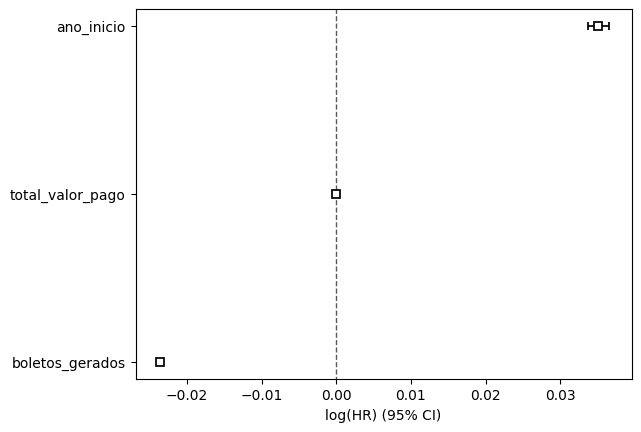

Tempo de vida esperado (Modelo de Cox): 3.13 anos
Tempo total de execução: 496.20 segundos


In [11]:
import time
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

# Ajustar os dados no PySpark para remover nulos e converter tipos
tabela_filtrada_2006 = tabela_filtrada_2006.withColumn("anos_contrato", col("anos_contrato").cast("double"))
tabela_filtrada_2006 = tabela_filtrada_2006.withColumn("churn", col("churn").cast("int"))
tabela_filtrada_2006 = tabela_filtrada_2006.withColumn("total_valor_pago", col("total_valor_pago").cast("double"))

start_time = time.time()

# Conversão para Pandas
df_pandas = tabela_filtrada_2006.select("anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio").toPandas()
print(f"Tempo para converter para Pandas: {time.time() - start_time:.2f} segundos")

# Criar DataFrame para o modelo de Cox
df_cox = df_pandas[["anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio"]]

# Aplicar modelo de Cox
cph = CoxPHFitter()
start_fit = time.time()
cph.fit(df_cox, duration_col="anos_contrato", event_col="churn")
print(f"Tempo para ajustar modelo de Cox: {time.time() - start_fit:.2f} segundos")

# Mostrar os coeficientes do modelo
cph.print_summary()

# Plotar hazard ratios
cph.plot()
plt.show()

# Obter a função de sobrevivência base do modelo de Cox
baseline_survival = cph.baseline_survival_

# Estimar o tempo de vida médio como a área abaixo da curva de sobrevivência base
tempo_de_vida_esperado_cox = np.trapz(baseline_survival["baseline survival"], baseline_survival.index)

print(f"Tempo de vida esperado (Modelo de Cox): {tempo_de_vida_esperado_cox:.2f} anos")

print(f"Tempo total de execução: {time.time() - start_time:.2f} segundos")


<lifelines.CoxPHFitter: fitted with 118012 total observations, 12791 right-censored observations>
             duration col = 'anos_contrato'
                event col = 'churn'
      baseline estimation = breslow
   number of observations = 118012
number of events observed = 105221
   partial log-likelihood = -1096936.29
         time fit was run = 2025-02-19 15:18:09 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
total_valor_pago -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
boletos_gerados  -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
ano_inicio        0.04      1.04      0.00            0.03            0.04                1.03                1.04

                  cmp to       z      p  -log2(p)
covariate                                        
total_valor_pago    0.00  -24.66 <0.005    443.60
boletos_gerados     0.00 -196.84 <0.005       inf
ano_inicio          0.00   47.77 <0.005       inf
---
Concordance = 0.84
Partial AIC = 2193878.58
log-likelihood ratio test = 80183.53 on 3 df
-log2(p) of ll-ratio test = inf

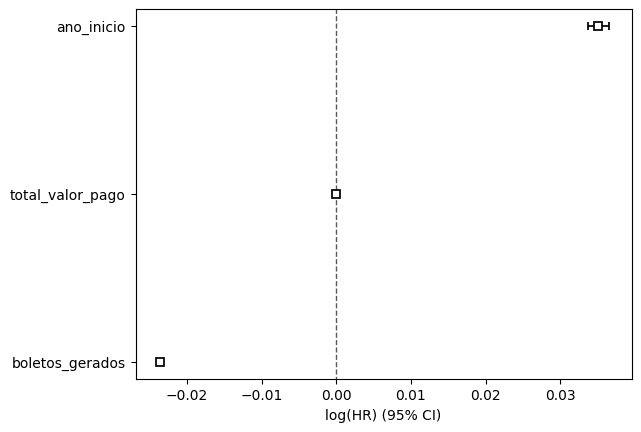

Tempo de vida esperado (Modelo de Cox): 3.79 anos


In [12]:
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

# 🔹 Ajustar os dados no PySpark para remover nulos e converter tipos
df_spark = tabela_filtrada_2006.withColumn("anos_contrato", col("anos_contrato").cast("double"))\
                               .withColumn("churn", col("churn").cast("int"))\
                               .withColumn("total_valor_pago", col("total_valor_pago").cast("double"))

# 🔹 Converter para Pandas
df_pandas = df_spark.select("anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio").toPandas()

# 🔹 Criar DataFrame para o modelo de Cox
df_cox = df_pandas[["anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio"]]

# 🔹 Aplicar modelo de Cox
cph = CoxPHFitter()
cph.fit(df_cox, duration_col="anos_contrato", event_col="churn")

# 🔹 Mostrar os coeficientes do modelo
cph.print_summary()

# 🔹 Plotar hazard ratios
cph.plot()
plt.show()

# 🔹 Estimar o tempo de vida médio usando a **média das expectativas individuais**
tempo_de_vida_esperado_cox = cph.predict_expectation(df_cox).mean()

print(f"Tempo de vida esperado (Modelo de Cox): {tempo_de_vida_esperado_cox:.2f} anos")


In [14]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter, WeibullFitter, CoxPHFitter
from pyspark.sql.functions import col, year, when

def calcular_sobrevivencia_kaplan(df_todos):
    resultados = []
    for ano_filtro in range(2006, 2007):
        df = df_todos.filter(
            (year(col("data_inicio")) >= ano_filtro) &
            (year(col("data_primeiro_boleto")) >= year(col("data_inicio")))
        )
        df = df.withColumn("anos_contrato", col("anos_contrato").cast("double"))\
               .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
        df_pandas = df.select("anos_contrato", "churn").toPandas()
        if df_pandas.empty:
            continue
        kmf = KaplanMeierFitter()
        kmf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])
        tempo_esperado = np.trapz(kmf.survival_function_["KM_estimate"], kmf.survival_function_.index)
        resultados.append((ano_filtro, tempo_esperado))
    return pd.DataFrame(resultados, columns=["Ano", "Kaplan-Meier"])

def calcular_sobrevivencia_weibull(df_todos):
    resultados = []
    for ano_filtro in range(2006, 2007):
        df = df_todos.filter(
            (year(col("data_inicio")) >= ano_filtro) &
            (year(col("data_primeiro_boleto")) >= year(col("data_inicio")))
        )
        df = df.withColumn("anos_contrato", col("anos_contrato").cast("double"))\
               .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
        df_pandas = df.select("anos_contrato", "churn").toPandas()
        if df_pandas.empty:
            continue
        wf = WeibullFitter()
        wf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])
        tempo_esperado = wf.lambda_ * np.math.gamma(1 + 1 / wf.rho_)
        resultados.append((ano_filtro, tempo_esperado))
    return pd.DataFrame(resultados, columns=["Ano", "Weibull"])

def calcular_sobrevivencia_cox(df_todos):
    resultados = []
    for ano_filtro in range(2006, 2007):
        df = df_todos.filter(
            (year(col("data_inicio")) >= ano_filtro) &
            (year(col("data_primeiro_boleto")) >= year(col("data_inicio")))
        )
        df = df.withColumn("anos_contrato", col("anos_contrato").cast("double"))\
               .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
        df_pandas = df.select("anos_contrato", "churn", "total_valor_pago", "boletos_gerados").toPandas()
        if df_pandas.empty:
            continue
        cph = CoxPHFitter()
        cph.fit(df_pandas, duration_col="anos_contrato", event_col="churn")
        tempo_esperado = cph.predict_expectation(df_pandas).mean()
        resultados.append((ano_filtro, tempo_esperado))
    return pd.DataFrame(resultados, columns=["Ano", "Cox"])

def plotar_grafico(df_kaplan, df_weibull, df_cox):
    df_final = df_kaplan.merge(df_weibull, on="Ano").merge(df_cox, on="Ano")
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df_final["Ano"].astype(str), y=df_final["Kaplan-Meier"],
                             mode="lines+markers", name="Kaplan-Meier", line=dict(color="blue")))
    fig.add_trace(go.Scatter(x=df_final["Ano"].astype(str), y=df_final["Weibull"],
                             mode="lines+markers", name="Weibull", line=dict(color="red")))
    fig.add_trace(go.Scatter(x=df_final["Ano"].astype(str), y=df_final["Cox"],
                             mode="lines+markers", name="Cox", line=dict(color="green")))
    fig.update_layout(
        title="Comparação do Tempo de Vida Esperado (Kaplan-Meier, Weibull, Cox)",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Vida Esperado (anos)",
        template="plotly_white",
        legend_title="Modelos"
    )
    fig.show()

def analisar_sobrevivencia_comparada(tabela_nova_sdf):
    df_kaplan = calcular_sobrevivencia_kaplan(tabela_nova_sdf)
    df_weibull = calcular_sobrevivencia_weibull(tabela_nova_sdf)
    df_cox = calcular_sobrevivencia_cox(tabela_nova_sdf)
    plotar_grafico(df_kaplan, df_weibull, df_cox)


In [15]:
df_kaplan = calcular_sobrevivencia_kaplan(tabela_nova_sdf)
df_weibull = calcular_sobrevivencia_weibull(tabela_nova_sdf)
df_cox = calcular_sobrevivencia_cox(tabela_nova_sdf)
plotar_grafico(df_kaplan, df_weibull, df_cox)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:2                                                                                    │
│                                                                                                  │
│   1 df_kaplan = calcular_sobrevivencia_kaplan(tabela_nova_sdf)                                   │
│ ❱ 2 df_weibull = calcular_sobrevivencia_weibull(tabela_nova_sdf)                                 │
│   3 df_cox = calcular_sobrevivencia_cox(tabela_nova_sdf)                                         │
│   4 plotar_grafico(df_kaplan, df_weibull, df_cox)                                                │
│   5                                                                                              │
│                                                                                                  │
│ in calcular_sobrevivencia_weibull:34                                                             │
│                                                                                                  │
│   31 │   │   )                                                                                   │
│   32 │   │   df = df.withColumn("anos_contrato", col("anos_contrato").cast("double"))\           │
│   33 │   │   │      .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))    │
│ ❱ 34 │   │   df_pandas = df.select("anos_contrato", "churn").toPandas()                          │
│   35 │   │   if df_pandas.empty:                                                                 │
│   36 │   │   │   continue                                                                        │
│   37 │   │   wf = WeibullFitter()                                                                │
│                                                                                                  │
│ c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packag │
│ es\pyspark\sql\connect\dataframe.py:1778 in toPandas                                             │
│                                                                                                  │
│   1775 │                                                                                         │
│   1776 │   def toPandas(self) -> "pandas.DataFrame":                                             │
│   1777 │   │   query = self._plan.to_proto(self._session.client)                                 │
│ ❱ 1778 │   │   return self._session.client.to_pandas(query, self._plan.observations)             │
│   1779 │                                                                                         │
│   1780 │   toPandas.__doc__ = PySparkDataFrame.toPandas.__doc__                                  │
│   1781                                                                                           │
│                                                                                                  │
│ c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packag │
│ es\pyspark\sql\connect\client\core.py:1002 in to_pandas                                          │
│                                                                                                  │
│    999 │   │   │   ("spark.sql.execution.arrow.pyspark.selfDestruct.enabled", "false"),          │
│   1000 │   │   )                                                                                 │
│   1001 │   │   self_destruct = cast(str, self_destruct_conf).lower() == "true"                   │
│ ❱ 1002 │   │   table, schema, metrics, observed_metrics, _ = self._execute_and_fetch(            │
│   1003 │   │   │   req, observations, self_destruct=self_destruct                                │
│   1004 │   │   )                                                                                 │
│   1005 │   │   assert table is not None                    

### Modelo de Machine Learning → Random Survival Forest (RSF)

In [40]:
import plotly.graph_objects as go
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
import pandas as pd
from pyspark.sql.functions import col

# Ajustar os dados no PySpark para remover nulos e converter tipos
df_spark = tabela_filtrada_2006 \
    .withColumn("anos_contrato", col("anos_contrato").cast("double")) \
    .withColumn("churn", col("churn").cast("int")) \
    .withColumn("total_valor_pago", col("total_valor_pago").cast("double"))

# Converter para Pandas e garantir que não há valores nulos
df_pandas = df_spark.select("anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio").toPandas()
df_pandas.dropna(inplace=True)  # Remove linhas com valores nulos

# Criar os dados no formato esperado pelo sksurv (sobrevivência)
X = df_pandas[["total_valor_pago"]]  # Apenas uma variável por simplicidade
y = Surv.from_arrays(event=df_pandas["churn"].astype(bool), time=df_pandas["anos_contrato"])

# Separar em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinar o modelo Random Survival Forest
rsf = RandomSurvivalForest(n_estimators=100, min_samples_split=10, random_state=42)
rsf.fit(X_train, y_train)

# Prever a função de sobrevivência para alguns exemplos do conjunto de teste
predictions = rsf.predict_survival_function(X_test)

# Criar gráfico interativo com Plotly
fig = go.Figure()

# Adicionar curva de sobrevivência de alguns clientes aleatórios
for i, fn in enumerate(predictions[:5]):  # Mostrando apenas 5 curvas para não poluir o gráfico
    survival_times = fn.x  # Eixo X do tempo previsto
    survival_probs = fn(survival_times)  # Avaliação da função de sobrevivência

    fig.add_trace(go.Scatter(
        x=survival_times,
        y=survival_probs,
        mode="lines",
        name=f"Cliente {i+1}"
    ))

# Configurar layout
fig.update_layout(
    title="Curvas de Sobrevivência Previstos pelo Random Survival Forest",
    xaxis_title="Tempo (anos)",
    yaxis_title="Probabilidade de Sobrevivência",
    template="plotly_white"
)

# Mostrar gráfico
fig.show()


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:27                                                                                   │
│                                                                                                  │
│   24                                                                                             │
│   25 # Treinar o modelo Random Survival Forest                                                   │
│   26 rsf = RandomSurvivalForest(n_estimators=100, min_samples_split=10, random_state=42)         │
│ ❱ 27 rsf.fit(X_train, y_train)                                                                   │
│   28                                                                                             │
│   29 # Prever a função de sobrevivência para alguns exemplos do conjunto de teste                │
│   30 predictions = rsf.predict_survival_function(X_test)                                         │
│                                                                                                  │
│ c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packag │
│ es\sksurv\ensemble\forest.py:171 in fit                                                          │
│                                                                                                  │
│   168 │   │   │   # that case. However, for joblib 0.12+ we respect any                          │
│   169 │   │   │   # parallel_backend contexts set at a higher level,                             │
│   170 │   │   │   # since correctness does not rely on using threads.                            │
│ ❱ 171 │   │   │   trees = Parallel(n_jobs=self.n_jobs, verbose=self.verbose, prefer="threads")   │
│   172 │   │   │   │   delayed(_parallel_build_trees)(                                            │
│   173 │   │   │   │   │   t,                                                                     │
│   174 │   │   │   │   │   self.bootstrap,                                                        │
│                                                                                                  │
│ c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packag │
│ es\joblib\parallel.py:1918 in __call__                                                           │
│                                                                                                  │
│   1915 │   │   │   # immediately to avoid overheads.                                             │
│   1916 │   │   │   output = self._get_sequential_output(iterable)                                │
│   1917 │   │   │   next(output)                                                                  │
│ ❱ 1918 │   │   │   return output if self.return_generator else list(output)                      │
│   1919 │   │                                                                                     │
│   1920 │   │   # Let's create an ID that uniquely identifies the current call. If the            │
│   1921 │   │   # call is interrupted early and that the same instance is immediately             │
│                                                                                                  │
│ c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packag │
│ es\joblib\parallel.py:1847 in _get_sequential_output                                             │
│                                                                                                  │
│   1844 │   │   │   for func, args, kwargs in iterable:                                           │
│   1845 │   │   │   │   self.n_dispatched_batches += 1                                            │
│   1846 │   │   │   │   self.n_dispatched_tasks += 1                                              │
│ ❱ 1847 │   │   │   │   res = func(*args, **kwargs)         

### Modelo de Competing Risks → Fine & Gray Model

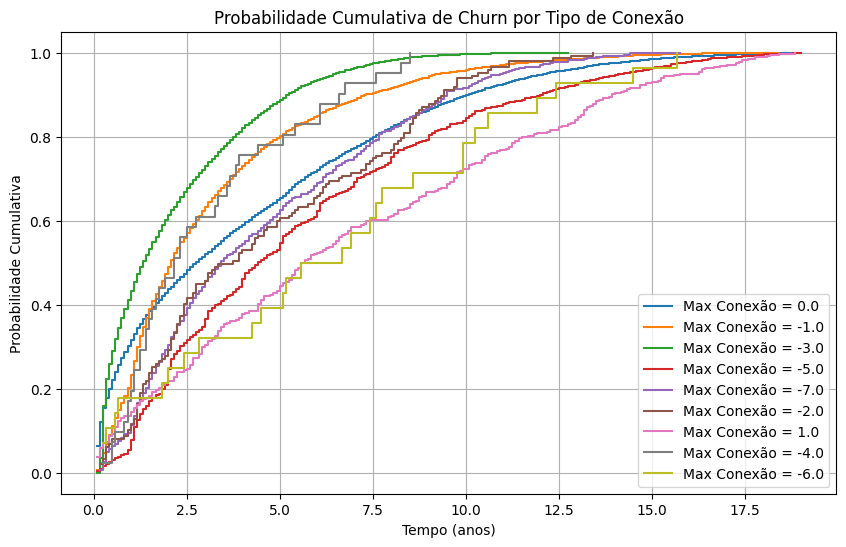

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import col
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.util import Surv

# Ajustar os dados no PySpark
df_spark = tabela_filtrada_2006 \
    .withColumn("anos_contrato", col("anos_contrato").cast("double")) \
    .withColumn("churn", col("churn").cast("int")) \
    .withColumn("total_valor_pago", col("total_valor_pago").cast("double")) \
    .withColumn("max_conexao", col("max_conexao").cast("int"))

# Converter para Pandas
df = df_spark.toPandas()

# Para cada valor único de max_conexao, calcular uma curva de Kaplan-Meier separada
valores_conexao = df["max_conexao"].unique()

plt.figure(figsize=(10, 6))
for conexao in valores_conexao:
    # Filtrar para um valor específico de max_conexao
    mask = df["max_conexao"] == conexao
    if mask.sum() > 10:  # Apenas plotar se houver dados suficientes
        time, survival_prob = kaplan_meier_estimator(
            df.loc[mask, "churn"].astype(bool),
            df.loc[mask, "anos_contrato"]
        )
        # Converter probabilidade de sobrevivência em probabilidade cumulativa do evento
        cumulative_prob = 1 - survival_prob
        plt.step(time, cumulative_prob, where="post", label=f"Max Conexão = {conexao}")

plt.title("Probabilidade Cumulativa de Churn por Tipo de Conexão")
plt.xlabel("Tempo (anos)")
plt.ylabel("Probabilidade Cumulativa")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# Primeiro vamos verificar quais funções estão disponíveis
import sksurv.nonparametric
print(dir(sksurv.nonparametric))

# Vamos verificar também a versão instalada
import sksurv
print(sksurv.__version__)

['BaseEstimator', 'CensoringDistributionEstimator', 'Interval', 'StrOptions', 'SurvivalFunctionEstimator', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_ci_logmlog', '_compute_counts', '_compute_counts_truncated', '_km_ci_estimator', 'check_array', 'check_consistent_length', 'check_is_fitted', 'check_y_survival', 'ipc_weights', 'kaplan_meier_estimator', 'nelson_aalen_estimator', 'np', 'numbers', 'stats']
0.23.1


In [37]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import col
from sksurv.nonparametric import aalen_johansen_estimator
from sksurv.util import Surv

# Ajustar os dados no PySpark para remover nulos e converter tipos
df_spark = tabela_filtrada_2006 \
    .withColumn("anos_contrato", col("anos_contrato").cast("double")) \
    .withColumn("churn", col("churn").cast("int")) \
    .withColumn("total_valor_pago", col("total_valor_pago").cast("double")) \
    .withColumn("max_conexao", col("max_conexao").cast("int"))  # Convertendo max_conexao para inteiro

# Converter para Pandas
df = df_spark.toPandas()

# Criar o dataset no formato de sobrevivência
y = Surv.from_arrays(event=df["churn"].astype(bool), time=df["anos_contrato"])

# Usar o estimador de Aalen-Johansen para a análise de riscos competitivos
time, estimate, count = aalen_johansen_estimator(y, df["max_conexao"])

# Plotar CIF para os diferentes eventos
plt.figure(figsize=(8, 5))
for i, (t, est) in enumerate(zip(time, estimate.T)):
    plt.step(t, est, where="post", label=f"Evento {i}")

plt.title("Aalen-Johansen: Competing Risks")
plt.xlabel("Tempo (anos)")
plt.ylabel("Probabilidade Cumulativa do Evento")
plt.legend()
plt.grid()
plt.show()

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:4                                                                                    │
│                                                                                                  │
│    1 import matplotlib.pyplot as plt                                                             │
│    2 import pandas as pd                                                                         │
│    3 from pyspark.sql.functions import col                                                       │
│ ❱  4 from sksurv.nonparametric import aalen_johansen_estimator                                   │
│    5 from sksurv.util import Surv                                                                │
│    6                                                                                             │
│    7 # Ajustar os dados no PySpark para remover nulos e converter tipos                          │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
ImportError: cannot import name 'aalen_johansen_estimator' from 'sksurv.nonparametric' 
(c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\sksurv\nonparam
etric.py)

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import col
from sksurv.competing_risk import CumulativeIncidenceFunction
from sksurv.util import Surv

# Ajustar os dados no PySpark para remover nulos e converter tipos
df_spark = tabela_filtrada_2006 \
    .withColumn("anos_contrato", col("anos_contrato").cast("double")) \
    .withColumn("churn", col("churn").cast("int")) \
    .withColumn("total_valor_pago", col("total_valor_pago").cast("double")) \
    .withColumn("max_conexao", col("max_conexao").cast("int"))  # Convertendo max_conexao para inteiro

# Converter para Pandas
df = df_spark.toPandas()

# Criar o dataset no formato de sobrevivência
y_cif = Surv.from_arrays(event=df["churn"].astype(bool), time=df["anos_contrato"])

# Criar o modelo de incidência cumulativa
cif_model = CumulativeIncidenceFunction()
cif_values = cif_model.fit(y_cif, df["max_conexao"])

# Plotar CIF para os diferentes eventos
plt.figure(figsize=(8, 5))
for key, cif in cif_values.items():
    plt.step(cif[0], cif[1], where="post", label=f"Evento {key}")

plt.title("Fine & Gray: Competing Risks")
plt.xlabel("Tempo (anos)")
plt.ylabel("Probabilidade Cumulativa do Evento")
plt.legend()
plt.grid()
plt.show()

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:4                                                                                    │
│                                                                                                  │
│    1 import matplotlib.pyplot as plt                                                             │
│    2 import pandas as pd                                                                         │
│    3 from pyspark.sql.functions import col                                                       │
│ ❱  4 from sksurv.competing_risk import CumulativeIncidenceFunction                               │
│    5 from sksurv.util import Surv                                                                │
│    6                                                                                             │
│    7 # Ajustar os dados no PySpark para remover nulos e converter tipos                          │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
ModuleNotFoundError: No module named 'sksurv.competing_risk'

- Se você quer uma abordagem simples para começar → Kaplan-Meier.
- Se você quer analisar o impacto de variáveis explicativas → Modelo de Cox.
- Se o tempo de sobrevivência segue um padrão conhecido → Weibull.
- Se quer usar aprendizado de máquina para capturar padrões complexos → RSF.
- Se há múltiplos eventos competindo → Fine & Gray.